# RISNet in Jupyter Notebook

This notebook demonstrates how to use RISNet in Jupyter for interactive RIS network simulations.

**Features:**
- Create and visualize RIS networks
- Run simulations interactively
- Analyze results with pandas
- Plot results with matplotlib
- Run batch parameter studies

## Setup and Imports

In [12]:
# Enable inline plotting
%matplotlib inline

# Auto-reload modules if they change
%load_ext autoreload
%autoreload 2

# Standard imports
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# RISNet imports
risnet_path = Path('.').resolve().parent.parent / 'risnet'
sys.path.insert(0, str(risnet_path))

from core import RISNetwork, Physics

print("✓ All imports successful")
print(f"✓ RISNet path: {risnet_path}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✓ All imports successful
✓ RISNet path: C:\Users\pc\Desktop\risnet


## 1. Create a Simple RIS Network

In [19]:
# Initialize network
net = RISNetwork()

# Add nodes
net.add_ap('AP1', 0, 0, power_dBm=20)
net.add_ris('RIS1', 5, 0, N=16, bits=2)
net.add_ue('UE1', 3.5, 1.5)

# Display network
print("Network nodes:")
net.list_nodes()

Network nodes:
AP1        AccessPoint('AP1', pos=[0.0, 0.0, 0.0])
RIS1       RIS('RIS1', pos=[5.0, 0.0, 0.0])
UE1        UE('UE1', pos=[3.5, 1.5, 0.0])


## 2. Run Basic Connection Test

In [25]:
# Connect AP -> RIS -> UE
result = net.connect('AP1', 'RIS1', 'UE1')

print("\nConnection Result:")
print(f"  SNR:         {result['snr_dB']:>8.2f} dB")
print(f"  Power:       {result['pwr_dBm']:>8.2f} dBm")
print(f"  Gain:        {result['gain_linear']:>8.2f} (linear)")
print(f"  Beam Angle:  {result['beam_angle']:>8.2f}°")

# Interpret SNR
snr = result['snr_dB']
if snr > 20:
    quality = "Excellent"
elif snr > 10:
    quality = "Good"
elif snr > 0:
    quality = "Fair"
else:
    quality = "Poor"

print(f"\nSignal Quality: {quality} ✓")


Connection Result:
  SNR:            48.77 dB
  Power:         -45.85 dBm
  Gain:        30373.18 (linear)
  Beam Angle:    135.00°

Signal Quality: Excellent ✓


## 3. Visualize Network Topology

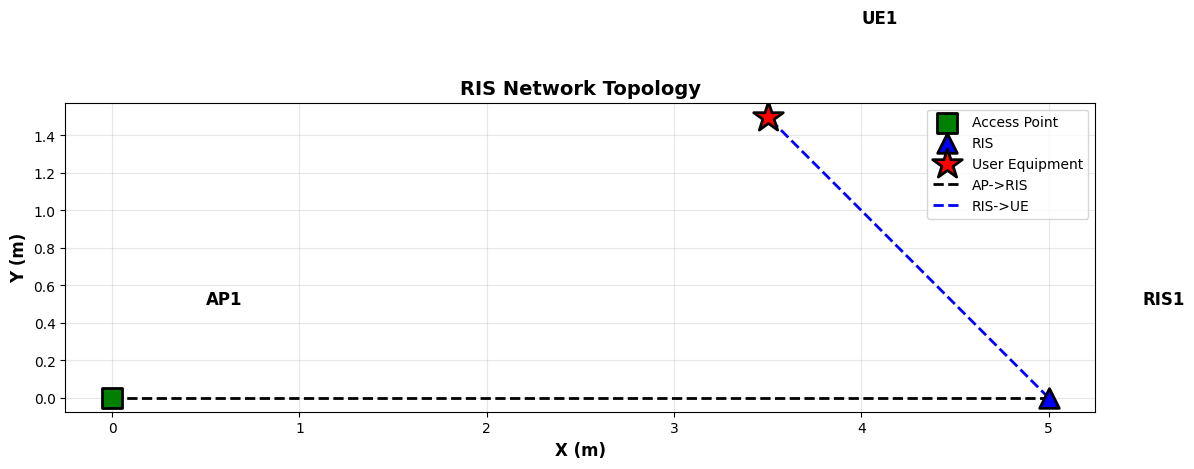

✓ Network visualization complete


In [26]:
# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Define styles
styles = {
    'AccessPoint': {'color': 'green', 'marker': 's', 'size': 200, 'label': 'Access Point'},
    'RIS': {'color': 'blue', 'marker': '^', 'size': 200, 'label': 'RIS'},
    'UE': {'color': 'red', 'marker': '*', 'size': 500, 'label': 'User Equipment'}
}

# Plot nodes
plotted = set()
for name, node in net.nodes.items():
    ntype = type(node).__name__
    style = styles[ntype]
    
    ax.scatter(node.pos[0], node.pos[1],
               color=style['color'],
               marker=style['marker'],
               s=style['size'],
               label=style['label'] if ntype not in plotted else '',
               edgecolors='black',
               linewidth=2,
               zorder=5)
    
    # Add label
    ax.text(node.pos[0] + 0.5, node.pos[1] + 0.5, name,
            fontsize=12, fontweight='bold', zorder=10)
    
    plotted.add(ntype)

# Draw path
ap = net.get('AP1')
ris = net.get('RIS1')
ue = net.get('UE1')

ax.plot([ap.pos[0], ris.pos[0]], [ap.pos[1], ris.pos[1]], 'k--', linewidth=2, label='AP->RIS')
ax.plot([ris.pos[0], ue.pos[0]], [ris.pos[1], ue.pos[1]], 'b--', linewidth=2, label='RIS->UE')

# Labels and formatting
ax.set_xlabel('X (m)', fontsize=12, fontweight='bold')
ax.set_ylabel('Y (m)', fontsize=12, fontweight='bold')
ax.set_title('RIS Network Topology', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='upper right')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print("✓ Network visualization complete")

## 4. Beam Sweeping Analysis

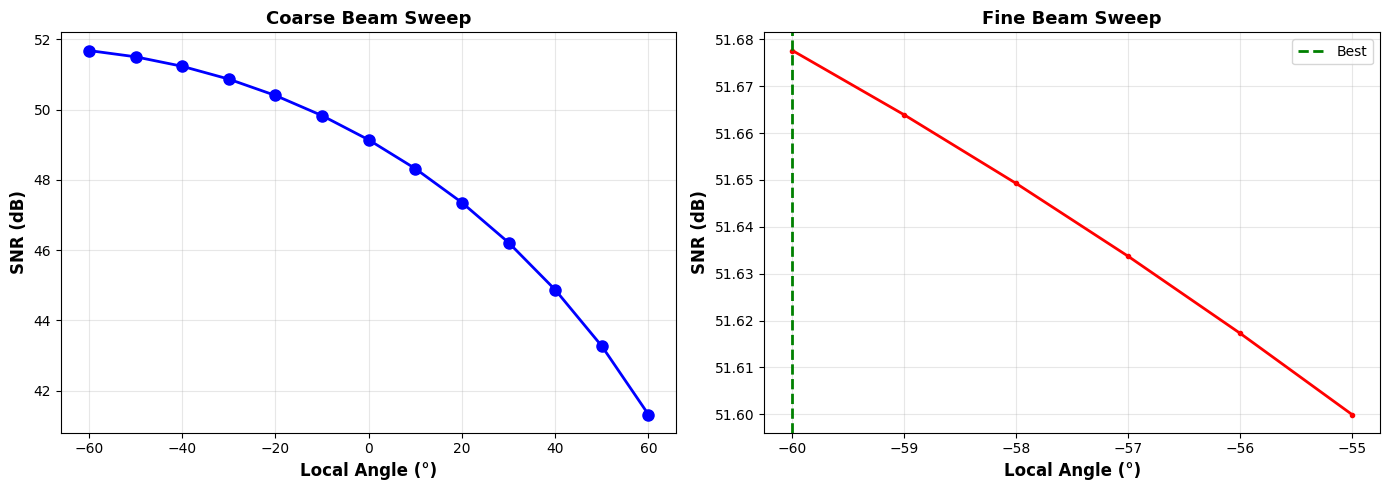


Beam Sweep Results:
  Best SNR:   51.68 dB
  Best angle: -60.00° (local)
  Best angle: -60.00° (absolute)


In [27]:
# Run beam sweep
sweep_result = net.sweep('AP1', 'RIS1', 'UE1', fov=60, step=10)

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot coarse sweep
axes[0].plot(sweep_result['local_coarse'], sweep_result['snr_coarse'], 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Local Angle (°)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('SNR (dB)', fontsize=12, fontweight='bold')
axes[0].set_title('Coarse Beam Sweep', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot fine sweep
axes[1].plot(sweep_result['local_fine'], sweep_result['snr_fine'], 'r.-', linewidth=2, markersize=6)
axes[1].axvline(sweep_result['best_local_fine'], color='g', linestyle='--', linewidth=2, label='Best')
axes[1].set_xlabel('Local Angle (°)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('SNR (dB)', fontsize=12, fontweight='bold')
axes[1].set_title('Fine Beam Sweep', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nBeam Sweep Results:")
print(f"  Best SNR:   {sweep_result['best_snr_fine']:.2f} dB")
print(f"  Best angle: {sweep_result['best_local_fine']:.2f}° (local)")
print(f"  Best angle: {sweep_result['best_local_fine'] + 0:.2f}° (absolute)")  # Note: need to calculate absolute angle

## 5. Distance vs SNR Study

In [28]:
# Vary UE distance and measure SNR
distances = np.linspace(5, 50, 10)
snr_values = []
power_values = []

print("Distance Study (AP->RIS->UE):")
print(f"{'Distance':<12} {'SNR (dB)':<12} {'Power (dBm)':<12}")
print("-" * 36)

for dist in distances:
    # Update UE position
    net.update_node_position('UE1', dist, 3)
    
    # Get connection result
    result = net.connect('AP1', 'RIS1', 'UE1')
    snr_values.append(result['snr_dB'])
    power_values.append(result['pwr_dBm'])
    
    print(f"{dist:<12.1f} {result['snr_dB']:<12.2f} {result['pwr_dBm']:<12.2f}")

# Create DataFrame
df_study = pd.DataFrame({
    'Distance (m)': distances,
    'SNR (dB)': snr_values,
    'Power (dBm)': power_values
})

print("\n✓ Distance study complete")

Distance Study (AP->RIS->UE):
Distance     SNR (dB)     Power (dBm) 
------------------------------------
5.0          48.37        -46.62      
10.0         42.99        -52.00      
15.0         37.93        -57.05      
20.0         34.62        -60.37      
25.0         31.61        -62.80      
30.0         30.29        -64.70      
35.0         28.72        -66.27      
40.0         27.40        -67.59      
45.0         26.24        -68.75      
50.0         25.23        -69.76      

✓ Distance study complete


## 6. Plot Distance Analysis

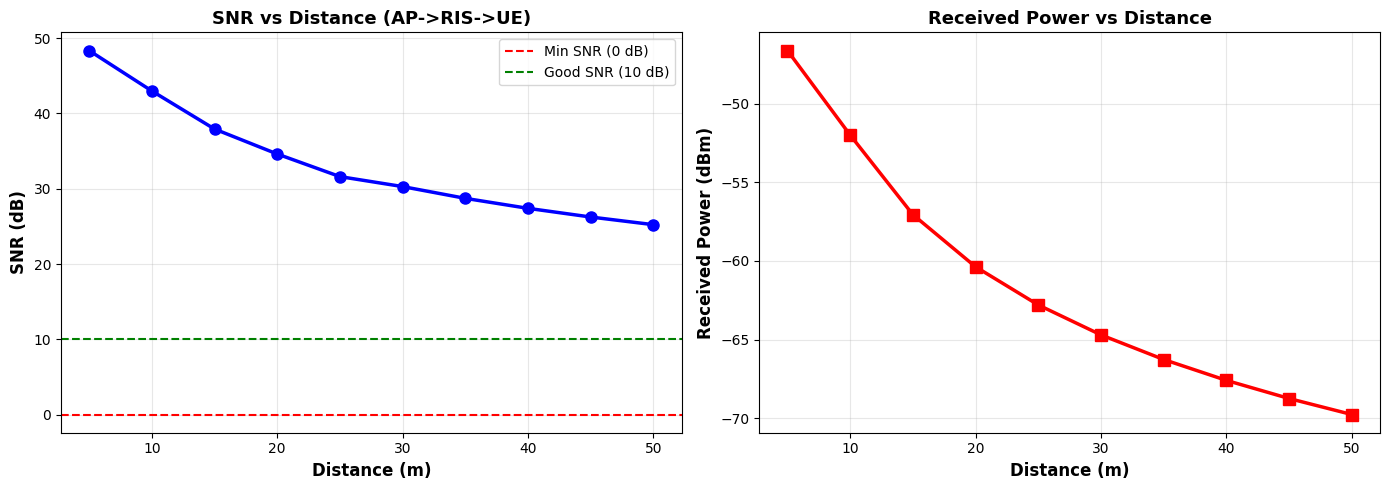


Distance Study Statistics:
       Distance (m)   SNR (dB)  Power (dBm)
count     10.000000  10.000000    10.000000
mean      27.500000  33.340304   -61.591540
std       15.138252   7.651253     7.638921
min        5.000000  25.225670   -69.764030
25%       16.250000  27.727906   -67.261794
50%       27.500000  30.950837   -63.749584
75%       38.750000  37.105441   -57.884259
max       50.000000  48.366182   -46.623518


In [29]:
# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SNR vs Distance
axes[0].plot(distances, snr_values, 'b-o', linewidth=2.5, markersize=8)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=1.5, label='Min SNR (0 dB)')
axes[0].axhline(y=10, color='g', linestyle='--', linewidth=1.5, label='Good SNR (10 dB)')
axes[0].set_xlabel('Distance (m)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('SNR (dB)', fontsize=12, fontweight='bold')
axes[0].set_title('SNR vs Distance (AP->RIS->UE)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

# Power vs Distance
axes[1].plot(distances, power_values, 'r-s', linewidth=2.5, markersize=8)
axes[1].set_xlabel('Distance (m)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Received Power (dBm)', fontsize=12, fontweight='bold')
axes[1].set_title('Received Power vs Distance', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print("\nDistance Study Statistics:")
print(df_study.describe().to_string())

## 7. RIS Array Size Impact

In [30]:
# Study effect of RIS array size
ris_sizes = [8, 16, 32, 64]
results = []

print("RIS Array Size Study:")
print(f"{'RIS Size':<12} {'Elements':<12} {'Gain (dBi)':<12} {'SNR (dB)':<12}")
print("-" * 48)

for N in ris_sizes:
    # Create new network with different RIS size
    net_test = RISNetwork()
    net_test.add_ap('AP', 0, 0)
    net_test.add_ris('RIS', 5, 0, N=N, bits=2)
    net_test.add_ue('UE', 15, 3)  # Far distance
    
    # Get connection result
    result = net_test.connect('AP', 'RIS', 'UE')
    
    # Calculate gain
    gain = Physics.array_gain_dBi(N*N)
    
    results.append({
        'N': N,
        'Elements': N*N,
        'Gain (dBi)': gain,
        'SNR (dB)': result['snr_dB']
    })
    
    print(f"{N}×{N:<6} {N*N:<12} {gain:<12.2f} {result['snr_dB']:<12.2f}")

df_array = pd.DataFrame(results)
print("\n✓ Array size study complete")

RIS Array Size Study:
RIS Size     Elements     Gain (dBi)   SNR (dB)    
------------------------------------------------
8×8      64           35.42        18.61       
16×16     256          47.46        37.93       
32×32     1024         59.51        49.98       
64×64     4096         71.55        61.70       

✓ Array size study complete


## 8. Plot Array Size Impact

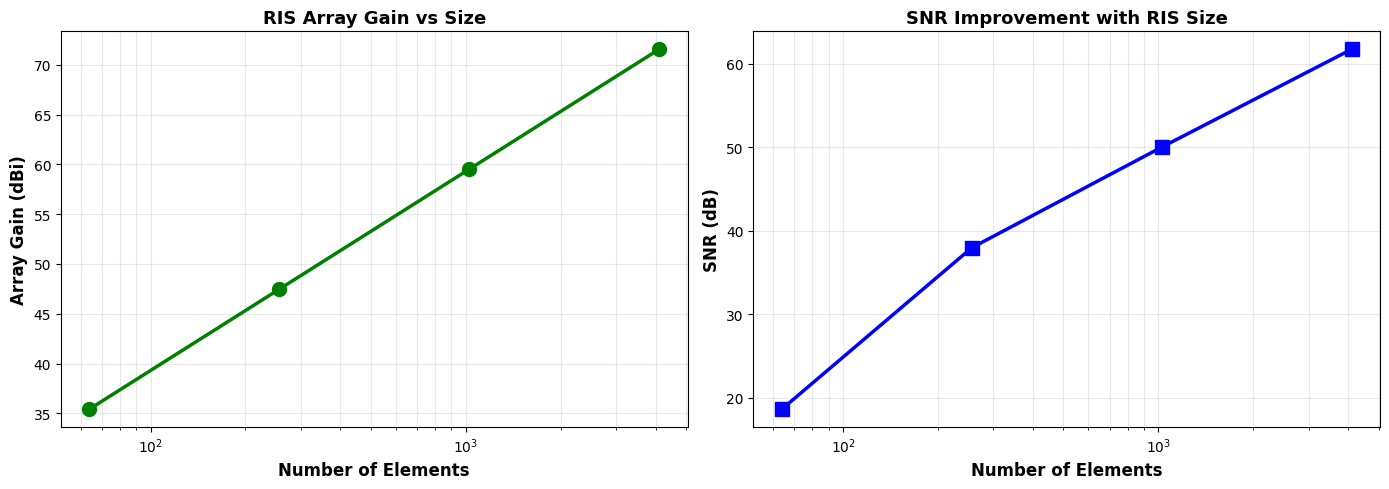


SNR Improvement (8×8 to 64×64): 43.09 dB
This represents 21.5x power improvement


In [31]:
# Plot array size impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Array gain
axes[0].plot(df_array['Elements'], df_array['Gain (dBi)'], 'go-', linewidth=2.5, markersize=10)
axes[0].set_xlabel('Number of Elements', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Array Gain (dBi)', fontsize=12, fontweight='bold')
axes[0].set_title('RIS Array Gain vs Size', fontsize=13, fontweight='bold')
axes[0].set_xscale('log')
axes[0].grid(True, alpha=0.3, which='both')

# SNR improvement
axes[1].plot(df_array['Elements'], df_array['SNR (dB)'], 'bs-', linewidth=2.5, markersize=10)
axes[1].set_xlabel('Number of Elements', fontsize=12, fontweight='bold')
axes[1].set_ylabel('SNR (dB)', fontsize=12, fontweight='bold')
axes[1].set_title('SNR Improvement with RIS Size', fontsize=13, fontweight='bold')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Calculate improvement
snr_8x8 = df_array[df_array['N'] == 8]['SNR (dB)'].values[0]
snr_64x64 = df_array[df_array['N'] == 64]['SNR (dB)'].values[0]
improvement = snr_64x64 - snr_8x8

print(f"\nSNR Improvement (8×8 to 64×64): {improvement:.2f} dB")
print(f"This represents {improvement/20*10:.1f}x power improvement")

## 9. Phase Quantization Analysis

In [32]:
# Study quantization loss
bits_range = range(1, 7)
quant_losses = []
snr_vals = []

print("Phase Quantization Study:")
print(f"{'Bits':<8} {'Levels':<8} {'Resolution':<12} {'Loss (dB)':<12} {'SNR Impact':<12}")
print("-" * 52)

for bits in bits_range:
    # Calculate loss
    loss = Physics.quantization_loss_dB(bits, model='standard')
    quant_losses.append(loss)
    
    # Create network with given bits
    net_quant = RISNetwork()
    net_quant.add_ap('AP', 0, 0)
    net_quant.add_ris('RIS', 5, 0, N=16, bits=bits)
    net_quant.add_ue('UE', 10, 3)
    
    result = net_quant.connect('AP', 'RIS', 'UE')
    snr_vals.append(result['snr_dB'])
    
    num_levels = 2**bits
    resolution = 360 / num_levels
    
    print(f"{bits:<8} {num_levels:<8} {resolution:<12.1f}° {loss:<12.4f} {result['snr_dB']:<12.2f}")

print("\n✓ Quantization study complete")

Phase Quantization Study:
Bits     Levels   Resolution   Loss (dB)    SNR Impact  
----------------------------------------------------
1        2        180.0       ° -1.6706      42.07       
2        4        90.0        ° -0.7453      42.91       
3        8        45.0        ° -0.5201      42.04       
4        16       22.5        ° -0.4641      42.16       
5        32       11.2        ° -0.4502      43.29       
6        64       5.6         ° -0.4467      42.12       

✓ Quantization study complete


## 10. Plot Quantization Analysis

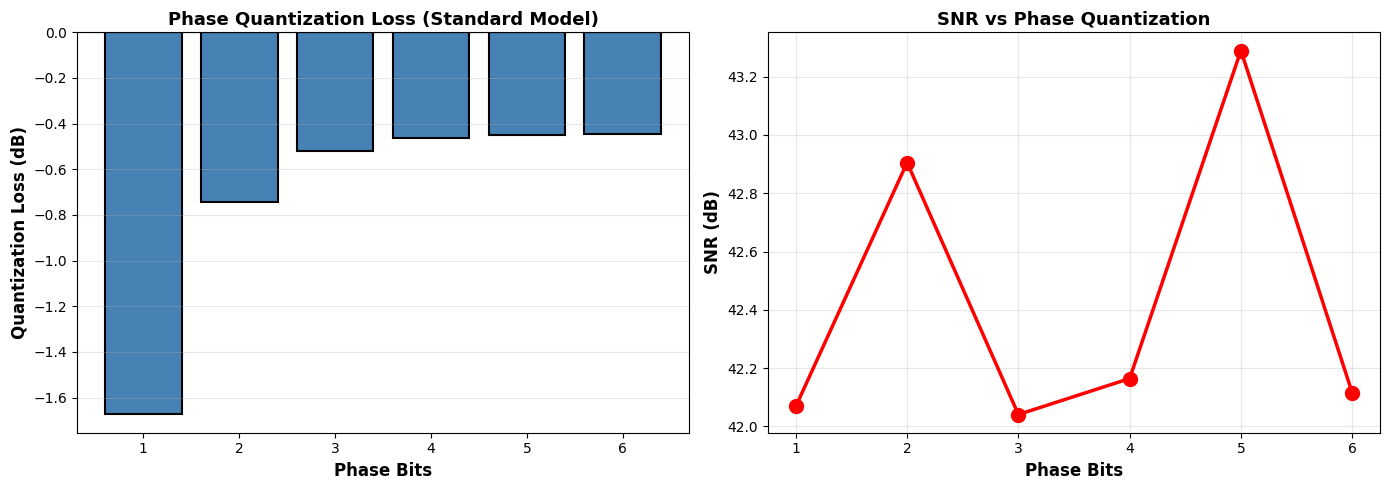


Key Findings:
  1-bit: -1.6706 dB loss
  2-bit: -0.7453 dB loss (most common)
  4-bit: -0.4641 dB loss (negligible)


In [33]:
# Plot quantization analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Quantization loss
axes[0].bar(list(bits_range), quant_losses, color='steelblue', edgecolor='black', linewidth=1.5)
axes[0].axhline(y=0, color='k', linestyle='-', linewidth=0.8)
axes[0].set_xlabel('Phase Bits', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Quantization Loss (dB)', fontsize=12, fontweight='bold')
axes[0].set_title('Phase Quantization Loss (Standard Model)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_xticks(list(bits_range))

# SNR vs bits
axes[1].plot(list(bits_range), snr_vals, 'ro-', linewidth=2.5, markersize=10)
axes[1].set_xlabel('Phase Bits', fontsize=12, fontweight='bold')
axes[1].set_ylabel('SNR (dB)', fontsize=12, fontweight='bold')
axes[1].set_title('SNR vs Phase Quantization', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(list(bits_range))

plt.tight_layout()
plt.show()

print(f"\nKey Findings:")
print(f"  1-bit: {quant_losses[0]:.4f} dB loss")
print(f"  2-bit: {quant_losses[1]:.4f} dB loss (most common)")
print(f"  4-bit: {quant_losses[3]:.4f} dB loss (negligible)")

## 11. Save Results

In [ ]:
# Save results to CSV
df_study.to_csv('distance_study_results.csv', index=False)
df_array.to_csv('array_size_study_results.csv', index=False)

print("✓ Results saved to CSV files:")
print("  - distance_study_results.csv")
print("  - array_size_study_results.csv")

# Display summary statistics
print("\n=== Summary Statistics ===")
print("\nDistance Study:")
print(df_study.describe().to_string())
print("\nArray Size Study:")
print(df_array.to_string())

## Summary

This notebook demonstrated:

✅ **Basic Usage**
- Creating RIS networks
- Adding nodes (AP, RIS, UE)
- Running simulations

✅ **Visualization**
- Network topology plots
- SNR and power analysis
- Beam sweeping results

✅ **Analysis**
- Distance impact on SNR
- RIS array size effects
- Phase quantization analysis

✅ **Data Science**
- Using pandas DataFrames
- Statistical analysis
- Saving results

**Key Insights:**
- SNR decreases with distance (path loss)
- Larger RIS arrays provide more gain
- Phase quantization has minimal impact for 3+ bits

**Next Steps:**
- Modify parameters and re-run
- Add more nodes and paths
- Compare different algorithms
- Generate publication-quality plots

Happy simulating! 🚀